In [43]:
! pip install pandas

### **1.0 Project Description**

This project focuses on analyzing and visualizing an international student application dataset containing 7,543 records and 80 variables related to student recruitment, demographics, academic preferences, application progress, and admission outcomes. The dataset includes information such as applicants' countries, universities, degree types, intended majors, application statuses, admission decisions, and recruitment activities. The objective of the project is to explore application trends, assess data quality, identify key patterns in student recruitment and admissions, and transform the findings into meaningful visualizations and an interactive dashboard. These insights will support data-driven decision-making by highlighting applicant demographics, recruitment performance, and admission outcomes.

### **1.2 Loading Necessary Libraries**

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re



### **1.2 Load the Dataset**

In [45]:
from google.colab import files
uploaded = files.upload()
#df = pd.read_csv(r"C:\Users\a-dmin\Documents\Data Science Projects\SchoolRecords\Data\DePaul_Data+-+DePaul_Data.csv")
#df.head(3)

Saving DePaul_Data+-+DePaul_Data.csv to DePaul_Data+-+DePaul_Data (2).csv


### **1.3 Dataset Familiarization Summary**

**Dataset Shape**

In [46]:
df = pd.read_csv('DePaul_Data+-+DePaul_Data.csv')

In [47]:
rows, cols = df.shape
print(f"The dataset contains {rows:,} rows and {cols} columns.")


The dataset contains 7,543 rows and 80 columns.


**Display Columns in the Dataset**

In [48]:
df.columns

Index(['Reference_ID', 'Given_Name', 'Last_Name', 'College', 'Major',
       'Degree_Type', 'Country', 'Recieved_At', 'Counsler', 'University',
       'Citizenship', 'Status', 'Intake', 'College_1st_Choice',
       'Major_1st_Choice', 'Phone_Number', 'Street_1', 'Street_2', 'Street_3',
       'City', 'Region', 'Postal', 'Email_ID', 'Date_of_Birth', 'Comments',
       'Phone_Number_2', 'Admit_Date', 'Most_Recent_Released_Decision',
       'RIT_Email_Created', 'Housing_Contract', 'Application_Source',
       'Is_Global_Grad', 'Is_Admitted', 'SEVIS_ID',
       'Official_University_email_address', 'Application_Agency_Code',
       'Created_At', 'Modified_At', 'Reference_ID-2', 'Recieved_At-2',
       'University-2', 'Outstanding_Checklist_Items',
       'Prior_I-20_Outreach_Detail', 'Prior_Non_I-20_Outreach_Detail',
       'Most_Recent_Contact', 'Most_Recent_User_and_Date',
       'Recent_GT_Form_Initiative', 'Date_of_Contact', 'Caller_Name',
       'Outcome_1', 'Remark', 'Caller_Name_2', 

**Check Data Type**

In [49]:
# Checking info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7543 entries, 0 to 7542
Data columns (total 80 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Reference_ID                       7543 non-null   int64  
 1   Given_Name                         7541 non-null   object 
 2   Last_Name                          7543 non-null   object 
 3   College                            7472 non-null   object 
 4   Major                              0 non-null      float64
 5   Degree_Type                        0 non-null      float64
 6   Country                            7532 non-null   object 
 7   Recieved_At                        7543 non-null   int64  
 8   Counsler                           0 non-null      float64
 9   University                         7543 non-null   object 
 10  Citizenship                        0 non-null      float64
 11  Status                             0 non-null      float

**Check for Missing Values**

In [50]:
pd.set_option('display.max_rows', None)
pd.DataFrame({
    'Missing': df.isnull().sum(),
    'Percent': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Missing', ascending=False)



,Missing,Percent
Degree_Type,7543,100.00
Major,7543,100.00
Citizenship,7543,100.00
Counsler,7543,100.00
Major_1st_Choice,7543,100.00
Status,7543,100.00
Prior_I-20_Outreach_Detail,7543,100.00
Outstanding_Checklist_Items,7543,100.00
Recent_GT_Form_Initiative,7543,100.00
Phone_Number_2,7543,100.00


**Check for Duplicates**

In [51]:
df.duplicated().sum()

np.int64(0)

Insights:
- The dataset contains 7,543 rows and 80 columns.
- The data appears to be related to student recruitment, admissions, and outreach activities, containing applicant details, university preferences, contact history, and campaign information.
- Several columns have substantial missing values, indicating potential data quality challenges that will need to be addressed before detailed analysis.
-





### **1.4 Data Dictionary**

| Variable Name                 | Data Type        | Description                                             | Notes                                   |
| ----------------------------- | ---------------- | ------------------------------------------------------- | --------------------------------------- |
| Reference_ID                  | Integer/String   | Unique identifier for each applicant record             | Primary identifier                      |
| Given_Name                    | String           | Applicant's first name                                  | Personal information                    |
| Last_Name                     | String           | Applicant's last name                                   | Personal information                    |
| College                       | String           | Institution associated with the applicant               | May contain combined university details |
| Major                         | String           | Intended field of study                                 | Some missing values observed            |
| Degree_Type                   | String           | Degree level being pursued (Bachelor's, Master's, etc.) | Check for consistency                   |
| Country                       | String           | Applicant's country of origin                           | Useful for demographic analysis         |
| Recieved_At                   | Integer/Datetime | Date application was received                           | May require timestamp conversion        |
| Counsler                      | String           | Assigned counselor                                      | Typo in column name ("Counsler")        |
| University                    | String           | University applied to                                   | May overlap with College field          |
| Citizenship                   | String           | Applicant's citizenship status                          | Useful for international analysis       |
| Status                        | String           | Current application status                              | Key analysis variable                   |
| Intake                        | String           | Intended enrollment term                                | e.g., Fall, Spring                      |
| College_1st_Choice            | String           | Applicant's first-choice college                        | Preference information                  |
| Major_1st_Choice              | String           | Applicant's first-choice major                          | Preference information                  |
| City                          | String           | Applicant's city                                        | Geographic analysis                     |
| Region                        | String           | Applicant's state/province/region                       | Geographic analysis                     |
| Email_ID                      | String           | Applicant email address                                 | Personal information                    |
| Date_of_Birth                 | Date             | Applicant's birth date                                  | May require formatting                  |
| Admit_Date                    | Date             | Date admission was granted                              | Useful for admissions analysis          |
| Most_Recent_Released_Decision | String           | Latest admission decision                               | Key outcome variable                    |
| Application_Source            | String           | Source of application lead                              | Recruitment analysis                    |
| Is_Global_Grad                | Boolean          | Indicates global graduate applicant                     | Yes/No field                            |
| Is_Admitted                   | Boolean          | Indicates admission outcome                             | Target variable                         |
| Outstanding_Checklist_Items   | String           | Remaining application requirements                      | May contain multiple values             |
| Most_Recent_Contact           | Date             | Latest communication date                               | Engagement tracking                     |
| Outcome_1                     | String           | First contact outcome                                   | Communication analysis                  |
| Outcome_2                     | String           | Second contact outcome                                  | Communication analysis                  |
| Final_Result                  | String           | Final recruitment/admission result                      | Important outcome variable              |
| Campaign_Id                   | String           | Recruitment campaign identifier                         | Marketing analysis                      |
| Escalation_Required           | Boolean          | Indicates whether escalation was needed                 | Process monitoring                      |
| I_901_Status                  | String           | I-901 fee/payment status                                | International student compliance        |
| Slate_Form_Filled             | Boolean          | Indicates whether Slate form was completed              | Application progress tracking           |
| Attempts                      | Integer          | Number of contact attempts                              | Recruitment effectiveness analysis      |
| City_and_Branch               | String           | Combined city and branch location                       | May require splitting                   |
| Type                          | String           | Communication or campaign type                          | Needs further investigation             |
| Header                        | String           | Campaign/message header                                 | Marketing-related field                 |
| Template                      | String           | Communication template used                             | Marketing-related field                 |


### **1.5 Data Quality Report**

 - Some columns are duplicated such:
Reference_ID-2
University-2
University-3
Degree_Type-2 Some columns are duplicated such:
Reference_ID-2
University-2
University-3
Degree_Type-2
Status-2
Created_At-2
Created_At-3

- Some columns have 100% missing values.
- Date fields are stored as strings instead of datetime format (e.g., Admit_Date, Date_of_Contact, Start_Date).
- Timestamp fields are stored as integers and require conversion to datetime (e.g., Created_At, Modified_At, Recieved_At).
- Column naming inconsistencies and spelling errors.

- Potential data entry/spelling errors in column names:

Recieved_At → should be Received_At
Counsler → should be Counselor.

- Column naming inconsistencies and spelling errors.
- Some variables have inappropriate data types, particularly date fields stored as strings and timestamps stored as integers, requiring preprocessing before analysis.



### **1.6 Exploratory Data Analysis (EDA) & Visualizations**

**Descriptive statistics for all numerical variables/ columns**

In [52]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

df[num_cols].describe().T[['mean', '50%', 'min', 'max']]

,mean,50%,min,max
Reference_ID,4.731908e+08,4.692245e+08,2.919250e+05,9.995188e+08
Major,NaN,NaN,NaN,NaN
Degree_Type,NaN,NaN,NaN,NaN
Recieved_At,1.757495e+12,1.757495e+12,1.757494e+12,1.757495e+12
Counsler,NaN,NaN,NaN,NaN
Citizenship,NaN,NaN,NaN,NaN
Status,NaN,NaN,NaN,NaN
Major_1st_Choice,NaN,NaN,NaN,NaN
Street_3,NaN,NaN,NaN,NaN
Date_of_Birth,NaN,NaN,NaN,NaN


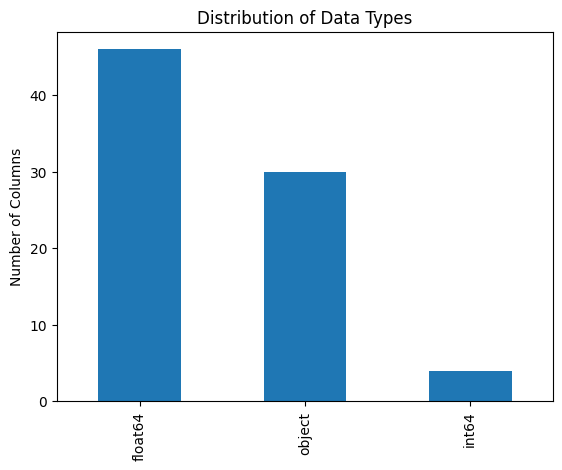

In [53]:
# Distribution of data types

df.dtypes.value_counts().plot(kind='bar')
plt.title('Distribution of Data Types')
plt.ylabel('Number of Columns')
plt.show()

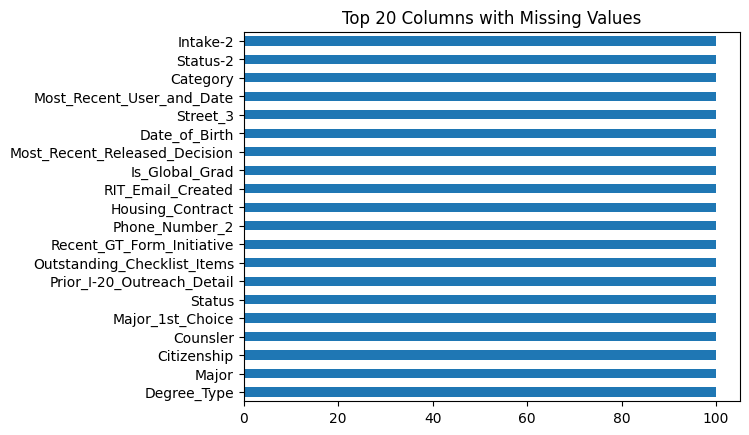

In [54]:
missing_pct = (df.isnull().sum()/len(df)*100)\
                .sort_values(ascending=False)

missing_pct.head(20).plot(kind='barh')
plt.title('Top 20 Columns with Missing Values')
plt.show()

### **1.7 Insights Summary**

- Duplicate columns identified:
Reference_ID-2
University-2
University-3
Degree_Type-2
Status-2
Created_At-2
Created_At-3
- Some columns contain 100% missing values.
- Several date fields are stored as strings instead of datetime format, including:
Admit_Date
Date_of_Contact
Start_Date
- Several timestamp fields are stored as integers and require conversion to datetime format, including:
Created_At
Modified_At
Recieved_At
- Column naming inconsistencies and spelling errors were detected:
Recieved_At → Received_At
Counsler → Counselor
- Some variables have inappropriate data types, particularly date and timestamp fields, requiring preprocessing before analysis.
Data cleaning and standardization are necessary to improve data quality, consistency, and readiness for analysis.

### **2.0 Dataset Cleaning**

### **2.1 Data Cleaning Log**

1. Drop Columns that are 100% empty

In [55]:
# Drop columns that are 100% missing
df.dropna(axis=1, how='all', inplace=True)

In [56]:
# Columns that have been dropped
dropped_columns = missing_pct[missing_pct == 100].index.tolist()
print("Dropped columns:", dropped_columns)

Dropped columns: ['Degree_Type', 'Major', 'Citizenship', 'Counsler', 'Major_1st_Choice', 'Status', 'Prior_I-20_Outreach_Detail', 'Outstanding_Checklist_Items', 'Recent_GT_Form_Initiative', 'Phone_Number_2', 'Housing_Contract', 'RIT_Email_Created', 'Is_Global_Grad', 'Most_Recent_Released_Decision', 'Date_of_Birth', 'Street_3', 'Most_Recent_User_and_Date', 'Category', 'Status-2', 'Intake-2', 'Region-2', 'Template', 'Header', 'City_and_Branch', 'Escalation_Required', 'SLU_Start_Comment', 'Prior_Non_I-20_Outreach_Detail', 'Most_Recent_Contact', 'Application_Agency_Code', 'Official_University_email_address', 'SEVIS_ID', 'Is_Admitted', 'Date_of_Contact_2', 'Outcome_2', 'SLU_Start_City', 'I_901_Status', 'Final_Result', 'Caller_Name_2']


In [57]:
# Shape of the dataset after empty columns dropped
print("Shape of the dataset after empty columns dropped:", df.shape)

Shape of the dataset after empty columns dropped: (7543, 42)


1. Duplicate columns identified:
Reference_ID-2
University-2
University-3
Degree_Type-2
Status-2
Created_At-2
Created_At-3

In [58]:
# Compare Duplicate Columns

# Reference_ID vs Reference_ID-2
# Checking if the columns are identical: True if all values are the same, False otherwise

(df['Reference_ID'] == df['Reference_ID-2']).all()


np.False_

In [59]:
duplicates = [
    ('Reference_ID', 'Reference_ID-2'),
    ('University', 'University-2'),
    ('University', 'University-3'),
    ('Degree_Type', 'Degree_Type-2'),
    ('Status', 'Status-2'),
    ('Created_At', 'Created_At-2'),
    ('Created_At', 'Created_At-3')
]

for col1, col2 in duplicates:
    if col1 in df.columns and col2 in df.columns:
        print(f"{col1} vs {col2}:",
              (df[col1] == df[col2]).all())

Reference_ID vs Reference_ID-2: False
University vs University-2: False
University vs University-3: False
Created_At vs Created_At-2: False
Created_At vs Created_At-3: False


In [60]:
# Based on the results, none of the columns are identical meaning we should keep all of them for further analysis.
# The columns are unique identifiers for each record, I will select one of them to keep and drop the others to avoid redundancy.
# I will keep 'Reference_ID' and drop 'Reference_ID-2' since it is the original name of the column and it is more intuitive.
# University-2 adds 0 values missing from University
# University-3, Created_At-2, Created_At-3 have some missing values and their original columns
# have no missing values, so I will keep the original columns and drop the duplicates.

In [61]:
# Drop duplicate columns
df.drop(columns=['University-3', 'Created_At-2', 'Created_At-3', 'Reference_ID-2', 'University-2', 'Modified_At-2', 'Modified_At-3'], inplace=True)

In [62]:
# Check for missing values in Street_1 and Street_2 columns
df[['Street_1', 'Street_2']].isnull().sum()

,0
Street_1,15
Street_2,4638


In [63]:
# Drop Street_2 column since it has over 98% missing values
df.drop(columns=['Street_2'], inplace=True)

In [64]:
df[['Remark', 'Remark_2']].isnull().sum()

,0
Remark,6869
Remark_2,7459


In [65]:
# Fill missing values in 'Remark' column with values from 'Remark_2' column
df['Remark'] = df['Remark'].fillna(df['Remark_2'])

In [66]:
# Drop Remark_2 column since its values have been used to fill missing values in Remark column
df.drop(columns=['Remark_2'], inplace=True)

In [67]:
# Drop column Remarks_2 since it has more than 88% missing values
df.drop(columns=['Remark'], inplace=True)

In [68]:
print("Number of columns:", df.shape[1])

Number of columns: 32


In [69]:
df.columns

Index(['Reference_ID', 'Given_Name', 'Last_Name', 'College', 'Country',
       'Recieved_At', 'University', 'Intake', 'College_1st_Choice',
       'Phone_Number', 'Street_1', 'City', 'Region', 'Postal', 'Email_ID',
       'Comments', 'Admit_Date', 'Application_Source', 'Created_At',
       'Modified_At', 'Recieved_At-2', 'Date_of_Contact', 'Caller_Name',
       'Outcome_1', 'Campaign_Id', 'Slate_Form_Filled', 'ID', 'Name',
       'Attempts', 'Degree_Type-2', 'Type', 'Start_Date'],
      dtype='object')

In [70]:
pd.set_option('display.max_rows', None)
pd.DataFrame({
    'Missing': df.isnull().sum(),
    'Percent': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Missing', ascending=False)



,Missing,Percent
Name,3316,43.96
Recieved_At-2,3194,42.34
Slate_Form_Filled,3194,42.34
Campaign_Id,3194,42.34
Start_Date,3194,42.34
Type,3194,42.34
Degree_Type-2,3194,42.34
ID,3194,42.34
Caller_Name,3194,42.34
Date_of_Contact,3194,42.34


**Dealing with Missing Values**

**a. High Missing values over 40%**

**b. Columns with Few Missing Numbers**

In [71]:
# Replace missing value in phone number with 'unknown'
df['Phone_Number'] = df['Phone_Number'].fillna('Unknown')

In [72]:
# Replace missing values in comments column with 'no comment'
df['Comments'] = df['Comments'].fillna('No Comment')

In [78]:
# Fill missing numbers with "Unknown"
for col in ['College', 'City', 'Country', 'Intake','Email_ID', 'Given_Name', 'College_1st_Choice', 'Street_1', 'Postal', 'Region']:
    df[col] = df[col].fillna('Unknown')

In [79]:
pd.set_option('display.max_rows', None)
pd.DataFrame({
    'Missing': df.isnull().sum(),
    'Percent': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Missing', ascending=False)

,Missing,Percent
Name,3316,43.96
Recieved_At-2,3194,42.34
Slate_Form_Filled,3194,42.34
Campaign_Id,3194,42.34
Start_Date,3194,42.34
Type,3194,42.34
Degree_Type-2,3194,42.34
ID,3194,42.34
Caller_Name,3194,42.34
Date_of_Contact,3194,42.34


### **2.2 Data Comparison Summary**

### **2.3 Cleaned Dataset**

### **2.4 Visualization Report**

### **2.5 Short Summary Report**